In [11]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

## Explanation

This file trains and runs LSTM models for 30, 50, and 70 cloudiness datasets using satellite data matched with NASA meteorological data. By comparing results to the model trained using just satellite data we can compare the importance of weather data in predicting log of cyanobacteria abundance. Hyperparameter testing occurred beforehand to determine loss functions and learning rates.

In [16]:
df1 = pd.read_csv('cloud_30_7_ww.csv')
print(df1.shape)

(33509, 23)


In [17]:
#sort
df1 = df1.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])

In [18]:
#prep data format for LSTM model
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge',
                'cloud_score', 'mean_diff_days', 'std_diff_days',
               'precip_3d_mm', 'wind_speed_ms', 'solar_rad_wm2']
xdata1 = []
ydata1 = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df1.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 7
    if len(group) == 7:
        seq = group[feature_cols].values

        #input features
        xdata1.append(seq)

        #target feature
        ydata1.append(group['cyanobacteria_abundance'].iloc[0])

xdata1 = np.array(xdata1)
ydata1 = np.array(ydata1)

#take log of cyanobacteria abundance
ydata1 = np.log1p(ydata1)

print("Shape of Data for 30% w/ weather")
print(xdata1.shape)

Shape of Data for 30% w/ weather
(4787, 7, 16)


In [19]:
#scaling features 
def scale_data(xdata, scaler=None, fit=True):
    n_samples, seq_len, n_features = xdata.shape
    x2d = xdata.reshape(-1, n_features)

    if fit:
        scaler = StandardScaler()
        x_scaled_2d = scaler.fit_transform(x2d)
    else:
        x_scaled_2d = scaler.transform(x2d)

    x_scaled = x_scaled_2d.reshape(n_samples, seq_len, n_features)

    return x_scaled, scaler

In [20]:
#LSTM class
#building LSTM class
import torch.nn as nn
import torch

#want to predict one value (cyanobacteria abundance)
class LSTMmodel(nn.Module):
    def __init__(self, input_size, hidden_size = 64, num_layers = 1):
        super().__init__()

        #initialize lstm model
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True 
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        last_out = lstm_out[:, -1, :]

        out = self.fc(last_out)
        return out

from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score

def run_kfold(X, y, hidden_size, num_layers, lr, loss_type, k=5):

    #print out specifics of this model
    print(f"hidden size = {hidden_size}, lr = {lr}, loss type = {loss_type}")
    
    kf = KFold(
        n_splits=k,
        shuffle=True,
        random_state=42
    )

    rmse_scores=[]
    r2_scores=[]

    for fold,(train_idx,val_idx) in enumerate(kf.split(X)):

        #loading data into dataloader
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]
        train_ds = TensorDataset(
            torch.tensor(X_train,dtype=torch.float32),
            torch.tensor(y_train,dtype=torch.float32)
        )
        val_ds = TensorDataset(
            torch.tensor(X_val,dtype=torch.float32),
            torch.tensor(y_val,dtype=torch.float32)
        )
        train_loader = DataLoader(
            train_ds,
            batch_size=32,
            shuffle=True
        )
        val_loader = DataLoader(
            val_ds,
            batch_size=32,
            shuffle=False
        )
        preds,true,model,rmse,r2 = run_model(
            train_loader,
            val_loader,
            X.shape[2],
            hidden_size,
            num_layers,
            lr,
            loss_type
        )

        #updating scores
        rmse_scores.append(rmse)
        r2_scores.append(r2)

    print(f"RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
    print(f"R2: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
    print()

    return rmse_scores,r2_scores

#tweaked run_model code to work with wrapper
def run_model(train_loader, val_loader, input_size, hidden_size, num_layers, learning_rate, loss_type):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    #change this to GRU or LSTM depending on what I want
    model = LSTMmodel(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    ).to(device)


    # loss function
    if loss_type == "mse":
        criterion = nn.MSELoss()

    elif loss_type == "mae":
        criterion = nn.L1Loss()

    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

    #iterations
    num_epochs = 30
    for epoch in range(num_epochs):
        #training
        model.train()
        train_loss=0
        for xbatch,ybatch in train_loader:
            xbatch=xbatch.to(device)
            ybatch=ybatch.to(device).view(-1,1)
            optimizer.zero_grad()
            preds=model(xbatch)
            loss=criterion(preds,ybatch)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()
        
        train_loss/=len(train_loader)

        #validation set
        model.eval()
        val_loss=0
        y_all=[]
        pred_all=[]
        with torch.no_grad():
            for xbatch,ybatch in val_loader:
                xbatch=xbatch.to(device)
                ybatch=ybatch.to(device).view(-1,1)
                preds=model(xbatch)
                loss=criterion(preds,ybatch)

                val_loss+=loss.item()

                y_all.append(ybatch.cpu())

                pred_all.append(preds.cpu())
        val_loss/=len(val_loader)

    #metrics
    y_all=torch.cat(y_all)
    pred_all=torch.cat(pred_all)
    pred_np=pred_all.numpy()
    y_np=y_all.numpy()

    #rmse
    rmse = np.sqrt(np.mean((pred_np-y_np)**2))

    #r2
    r2 = r2_score(y_np,pred_np)
    return (pred_all, y_all, model, rmse, r2)

In [21]:
#train final model pipeline 
def run_model_no_kfold(
    X_train, y_train,
    X_val, y_val,
    input_size,
    hidden_size=64,
    num_layers=1,
    learning_rate=0.001,
    loss_type="mse",
    batch_size=32,
    num_epochs=30):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # build datasets
    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )

    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )

    # loaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # model
    model = LSTMmodel(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    ).to(device)

    # loss
    if loss_type == "mse":
        criterion = nn.MSELoss()
    elif loss_type == "mae":
        criterion = nn.L1Loss()
    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # training loop
    for epoch in range(num_epochs):

        model.train()
        train_loss = 0

        for xbatch, ybatch in train_loader:
            xbatch = xbatch.to(device)
            ybatch = ybatch.to(device).view(-1,1)

            optimizer.zero_grad()
            preds = model(xbatch)  # make sure model returns [batch,1]
            loss = criterion(preds, ybatch)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # validation
        model.eval()
        val_loss = 0
        y_all, pred_all = [], []

        with torch.no_grad():
            for xbatch, ybatch in val_loader:
                xbatch = xbatch.to(device)
                ybatch = ybatch.to(device).view(-1,1)

                preds = model(xbatch)
                loss = criterion(preds, ybatch)

                val_loss += loss.item()

                y_all.append(ybatch.cpu())
                pred_all.append(preds.cpu())

        val_loss /= len(val_loader)

    # metrics
    y_all = torch.cat(y_all)
    pred_all = torch.cat(pred_all)

    y_np = y_all.numpy().ravel()
    pred_np = pred_all.numpy().ravel()

    rmse = np.sqrt(np.mean((pred_np - y_np) ** 2))
    r2 = r2_score(y_np, pred_np)

    return pred_all, y_all, model, rmse, r2


In [22]:
from sklearn.model_selection import train_test_split

xtrain1, xtest1, ytrain1, ytest1 = train_test_split(xdata1, ydata1, test_size = 0.1, random_state = 999)
xtrain1, scaler = scale_data(xtrain1, fit=True)

hidden size = 32, lr = 0.01, loss type = mse
RMSE: 1.690 ± 0.068
R2: 0.654 ± 0.028

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 1.685 ± 0.094
R2: 0.656 ± 0.038

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 1.702 ± 0.091
R2: 0.649 ± 0.036

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 1.773 ± 0.075
R2: 0.619 ± 0.039

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 1.681 ± 0.085
R2: 0.656 ± 0.044



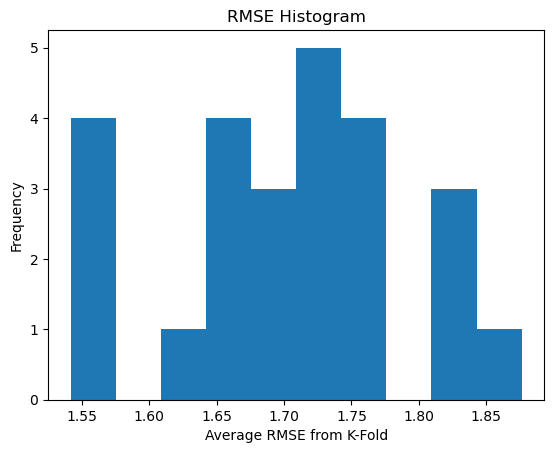

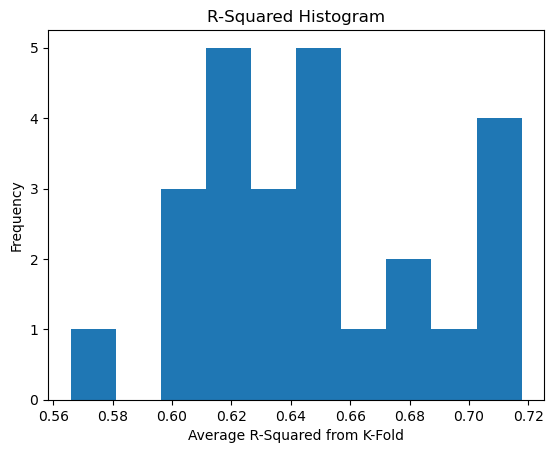

In [13]:
#train models 
#model 1
rmse_1, r2_1 = run_kfold(xtrain1, ytrain1, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(xtrain1, ytrain1, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(xtrain1, ytrain1, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(xtrain1, ytrain1, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(xtrain1, ytrain1, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

Test RMSE: 1.5526853
Test R2: 0.7190532684326172


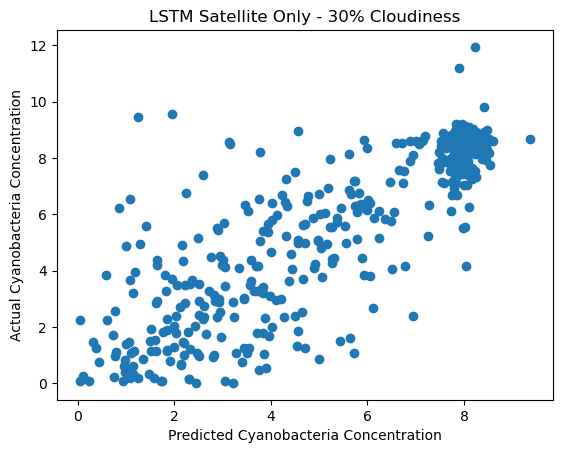

In [23]:
#train final model and run on the test set 
xtest1, _ = scale_data(xtest1, scaler=scaler, fit=False)
preds, y_true, model, rmse, r2 = run_model_no_kfold(
    xtrain1, ytrain1,
    xtest1, ytest1,
    input_size=xtrain1.shape[2],
    hidden_size=32,
    num_layers=1,
    learning_rate=0.01,
    loss_type="mse"
)

print("Test RMSE:", rmse)
preds = preds.numpy()
y_true = y_true.numpy()
r2 = r2_score(y_true, preds)
print("Test R2:", r2)

plt.scatter(preds, y_true)
plt.xlabel("Predicted Cyanobacteria Concentration")
plt.ylabel("Actual Cyanobacteria Concentration")
plt.title("LSTM Satellite Only - 30% Cloudiness")
plt.show()

#### 50% Cloudiness Model

In [31]:
df2 = pd.read_csv('cloud_50_8_ww.csv')
print(df2.shape)

(43184, 23)


In [32]:
#sort
df2 = df2.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])

In [33]:
#prep data format for LSTM model
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge',
                'cloud_score', 'mean_diff_days', 'std_diff_days',
               'precip_3d_mm', 'wind_speed_ms', 'solar_rad_wm2']
xdata2 = []
ydata2 = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df2.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 8
    if len(group) == 8:
        seq = group[feature_cols].values

        #input features
        xdata2.append(seq)

        #target feature
        ydata2.append(group['cyanobacteria_abundance'].iloc[0])

xdata2 = np.array(xdata2)
ydata2 = np.array(ydata2)

#take log of cyanobacteria abundance
ydata2 = np.log1p(ydata2)

print("Shape of Data for 50% w/ weather")
print(xdata2.shape)

Shape of Data for 50% w/ weather
(5398, 8, 16)


In [34]:
#train test split
xtrain2, xtest2, ytrain2, ytest2 = train_test_split(xdata2, ydata2, test_size = 0.1, random_state = 999)
xtrain2, scaler = scale_data(xtrain2, fit=True)

hidden size = 32, lr = 0.01, loss type = mse
RMSE: 1.734 ± 0.048
R2: 0.651 ± 0.019

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 1.707 ± 0.074
R2: 0.661 ± 0.024

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 1.712 ± 0.028
R2: 0.659 ± 0.017

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 1.792 ± 0.039
R2: 0.627 ± 0.012

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 1.757 ± 0.075
R2: 0.641 ± 0.027



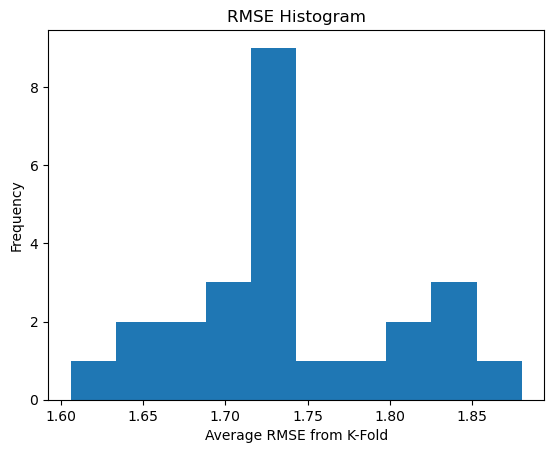

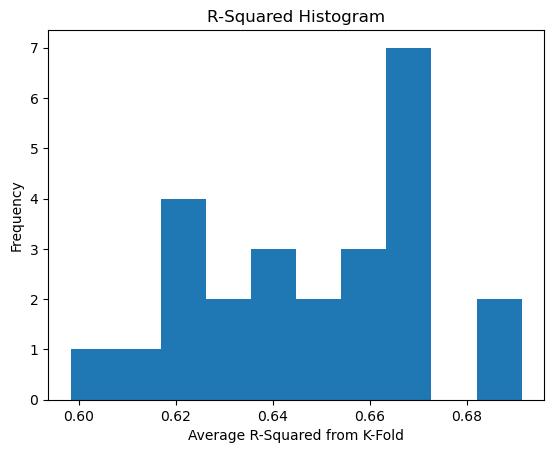

In [35]:
#running k-fold on different model varieties - 50%

#model 1
rmse_1, r2_1 = run_kfold(xtrain2, ytrain2, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(xtrain2, ytrain2, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(xtrain2, ytrain2, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(xtrain2, ytrain2, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(xtrain2, ytrain2, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

Test RMSE: 1.5685673
Test R2: 0.6942094564437866


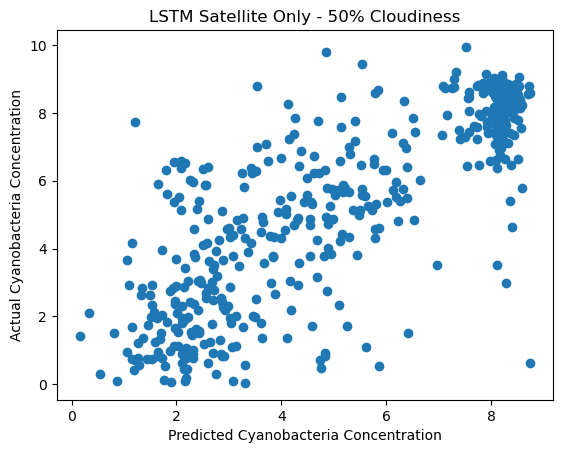

In [36]:
#train final model and run on the test set 
xtest2, _ = scale_data(xtest2, scaler=scaler, fit=False)
preds, y_true, model, rmse, r2 = run_model_no_kfold(
    xtrain2, ytrain2,
    xtest2, ytest2,
    input_size=xtrain2.shape[2],
    hidden_size=16,
    num_layers=1,
    learning_rate=0.01,
    loss_type="mse"
)

print("Test RMSE:", rmse)
preds = preds.numpy()
y_true = y_true.numpy()
r2 = r2_score(y_true, preds)
print("Test R2:", r2)

plt.scatter(preds, y_true)
plt.xlabel("Predicted Cyanobacteria Concentration")
plt.ylabel("Actual Cyanobacteria Concentration")
plt.title("LSTM Satellite Only - 50% Cloudiness")
plt.show()

#### 70% Cloudiness Model

In [44]:
df3 = pd.read_csv('cloud_70_9_ww.csv')
print(df3.shape)

(50580, 23)


In [45]:
#sort
df3 = df3.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])

In [46]:
#prep data format for LSTM model
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge',
                'cloud_score', 'mean_diff_days', 'std_diff_days',
               'precip_3d_mm', 'wind_speed_ms', 'solar_rad_wm2']
xdata3 = []
ydata3 = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df3.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 9
    if len(group) == 9:
        seq = group[feature_cols].values

        #input features
        xdata3.append(seq)

        #target feature
        ydata3.append(group['cyanobacteria_abundance'].iloc[0])

xdata3 = np.array(xdata3)
ydata3 = np.array(ydata3)

#take log of cyanobacteria abundance
ydata3 = np.log1p(ydata3)

print("Shape of Data for 70% w/ weather")
print(xdata3.shape)

Shape of Data for 70% w/ weather
(5620, 9, 16)


In [47]:
#train test split
xtrain3, xtest3, ytrain3, ytest3 = train_test_split(xdata3, ydata3, test_size = 0.1, random_state = 999)
xtrain3, scaler = scale_data(xtrain3, fit=True)

hidden size = 32, lr = 0.01, loss type = mse
RMSE: 1.744 ± 0.058
R2: 0.646 ± 0.024

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 1.726 ± 0.038
R2: 0.654 ± 0.013

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 1.741 ± 0.064
R2: 0.647 ± 0.026

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 1.864 ± 0.142
R2: 0.595 ± 0.059

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 1.760 ± 0.093
R2: 0.639 ± 0.040



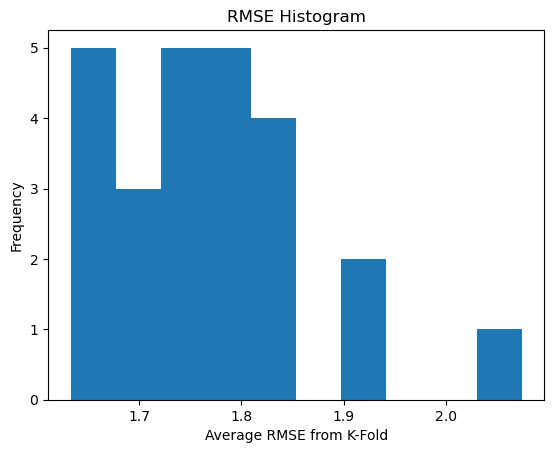

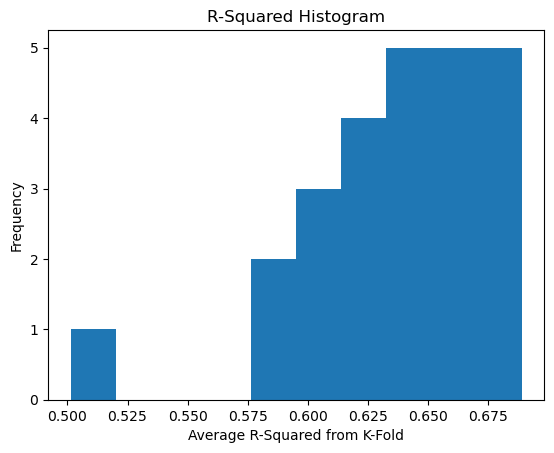

In [41]:
#running k-fold on different model varieties - 70%

#model 1
rmse_1, r2_1 = run_kfold(xtrain3, ytrain3, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(xtrain3, ytrain3, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(xtrain3, ytrain3, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(xtrain3, ytrain3, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(xtrain3, ytrain3, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

Test RMSE: 1.6409361
Test R2: 0.7004721164703369


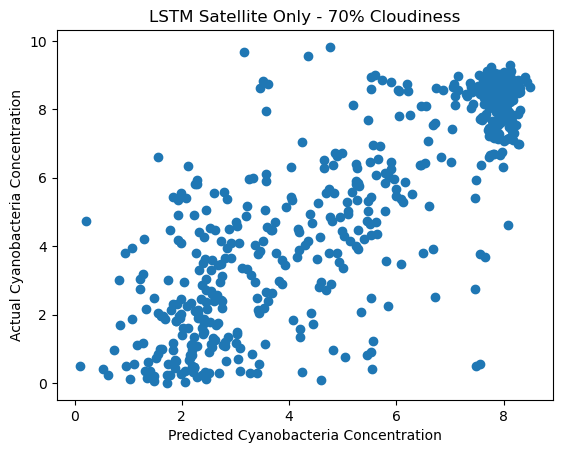

In [48]:
#train final model and run on the test set 
xtest3, _ = scale_data(xtest3, scaler=scaler, fit=False)
preds, y_true, model, rmse, r2 = run_model_no_kfold(
    xtrain3, ytrain3,
    xtest3, ytest3,
    input_size=xtrain3.shape[2],
    hidden_size=16,
    num_layers=1,
    learning_rate=0.01,
    loss_type="mse"
)

print("Test RMSE:", rmse)
preds = preds.numpy()
y_true = y_true.numpy()
r2 = r2_score(y_true, preds)
print("Test R2:", r2)

plt.scatter(preds, y_true)
plt.xlabel("Predicted Cyanobacteria Concentration")
plt.ylabel("Actual Cyanobacteria Concentration")
plt.title("LSTM Satellite Only - 70% Cloudiness")
plt.show()